In [2]:
# ── EDA: Exploratory Data Analysis ──────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (3163, 21)

First 5 rows:


,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,...,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U
0,1,72.0,1,0,0,0,0,0,0,0,...,0,0,0,1,30.0,1,1,1,1,0
1,1,15.0,0,1,0,0,0,0,0,0,...,0,0,0,1,145.0,1,1,1,1,0
2,1,24.0,1,0,0,0,0,0,0,0,...,0,0,0,1,0.0,1,1,1,1,0
3,1,24.0,0,0,0,0,0,0,0,0,...,0,0,0,1,430.0,1,1,1,1,0
4,1,77.0,1,0,0,0,0,0,0,0,...,0,0,0,1,7.3,1,1,1,1,0


Target Distribution:
target
0    3012
1     151
Name: count, dtype: int64

Normal:      3012 patients
Hypothyroid: 151 patients


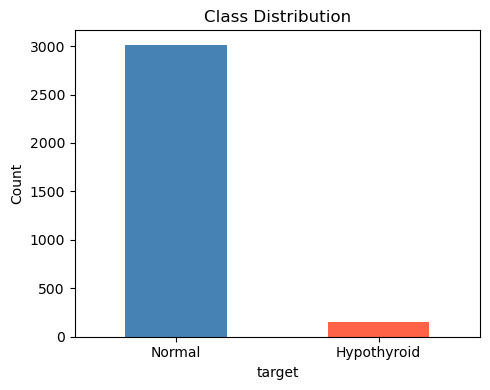

In [3]:
# Class distribution
print("Target Distribution:")
print(df['target'].value_counts())
print(f"\nNormal:      {(df['target']==0).sum()} patients")
print(f"Hypothyroid: {(df['target']==1).sum()} patients")

plt.figure(figsize=(5,4))
df['target'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.xticks([0,1], ['Normal','Hypothyroid'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/eda_class_distribution.png', dpi=150)
plt.show()

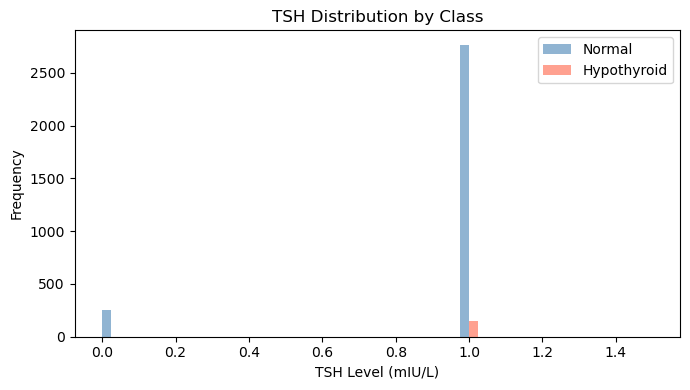

In [4]:
# TSH distribution by class
plt.figure(figsize=(7,4))
df[df['target']==0]['TSH'].plot(kind='hist', bins=40, alpha=0.6, label='Normal', color='steelblue')
df[df['target']==1]['TSH'].plot(kind='hist', bins=40, alpha=0.6, label='Hypothyroid', color='tomato')
plt.xlabel('TSH Level (mIU/L)')
plt.title('TSH Distribution by Class')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/eda_tsh_distribution.png', dpi=150)
plt.show()

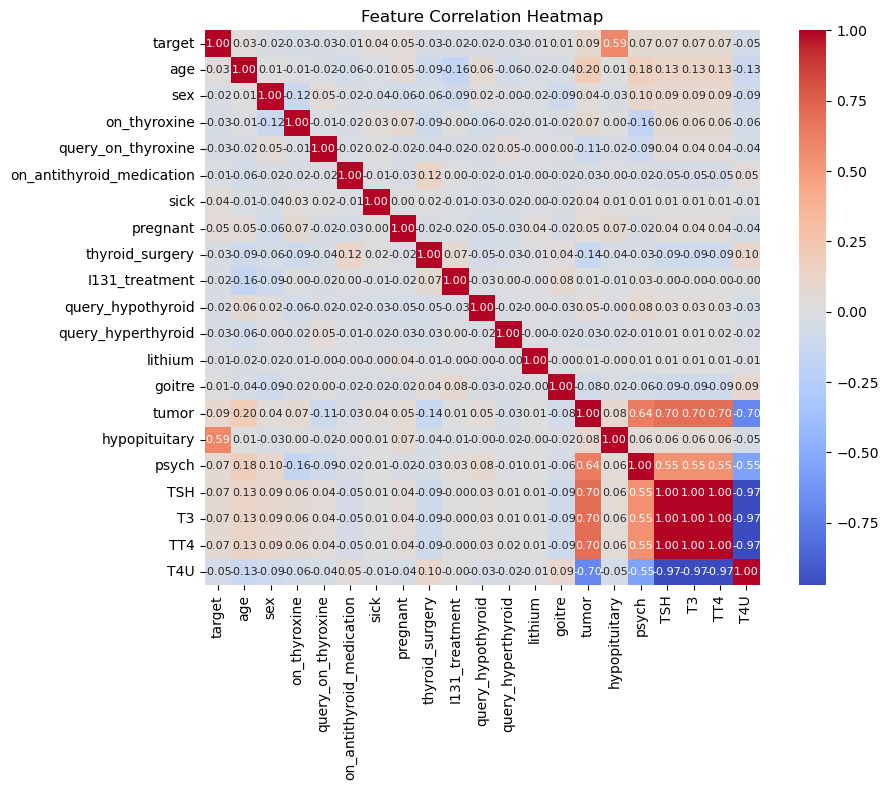

In [5]:
# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={'size':8}, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/eda_correlation_heatmap.png', dpi=150)
plt.show()

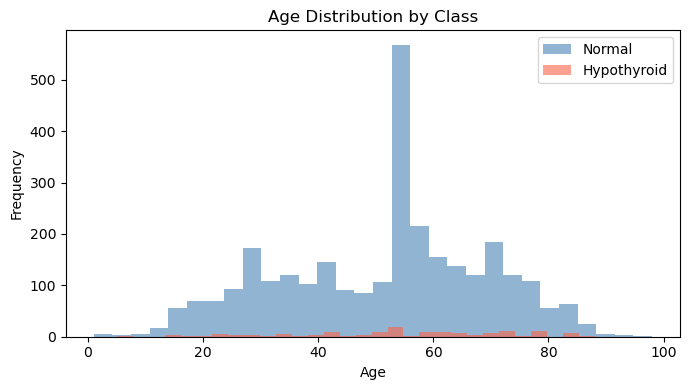

In [6]:
# Age distribution by class
plt.figure(figsize=(7,4))
df[df['target']==0]['age'].plot(kind='hist', bins=30, alpha=0.6, label='Normal', color='steelblue')
df[df['target']==1]['age'].plot(kind='hist', bins=30, alpha=0.6, label='Hypothyroid', color='tomato')
plt.xlabel('Age')
plt.title('Age Distribution by Class')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/eda_age_distribution.png', dpi=150)
plt.show()

In [7]:
# Basic statistics summary
print("=== Numerical Feature Statistics ===")
df.describe().round(2)

=== Numerical Feature Statistics ===


,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,...,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U
count,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00,...,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00,3163.00
mean,0.05,51.56,0.29,0.15,0.02,0.01,0.03,0.08,0.08,0.02,...,0.01,0.00,0.03,0.85,5.15,0.78,0.92,0.92,0.92,0.08
std,0.21,17.91,0.45,0.35,0.13,0.11,0.18,0.27,0.27,0.14,...,0.11,0.03,0.17,0.36,22.14,0.41,0.27,0.27,0.27,0.27
min,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,38.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.00,1.00,1.00,1.00,1.00,0.00
50%,0.00,54.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.70,1.00,1.00,1.00,1.00,0.00
75%,0.00,64.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,1.80,1.00,1.00,1.00,1.00,0.00
max,1.00,98.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,530.00,1.00,1.00,1.00,1.00,1.00
